**TAREA TRELLO: SPRINT-S1_DS-01: Crear dataset de contenido técnico (EDA)**


https://trello.com/c/vRAykzCf/51-sprint-s1ds-01-crear-dataset-de-contenido-t%C3%A9cnico


**IMPORTANTE:** Almacenar Archivos resultantes en su Ruta DRIVE, ya que al dejarlo en /content/sample_data/ como está en el Notebook, al desconectarse se elimina automáticamente.

**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

**RECOPILACION DE DATOS (NoSintacticos) - Origen Dev.to**

Dev.to es una comunidad gigante de desarrolladores. Su API es gratuita y no requiere autenticación compleja para lecturas básicas.

DEV.to provee una API pública oficial estructurada para desarrolladores url = f"https://dev.to/api/articles?tag={tag}&per_page={PER_PAGE}&page={page}"

_______________________________________

Filtrado de Artículos Irrelevantes
Para mejorar la relevancia de los artículos recolectados, implementamos un proceso de filtrado que considera dos criterios principales:

1.- **Palabras Clave de Exclusión**: Identificaremos y descartaremos artículos que contengan ciertas palabras clave en sus títulos o descripciones que suelen indicar contenido superficial, promocional o de opinión no deseada (ej. "meme", "promoción", "opinión", "noticias").


2.- **Longitud Mínima del Texto**: Artículos excesivamente cortos a menudo carecen de la profundidad necesaria. Estableceremos una longitud mínima para la descripción (texto) de cada artículo para asegurar que contengan suficiente información sustancial.

In [ ]:
import requests
import pandas as pd
import numpy as np # Importar numpy para consistencia


# Mapeo de categorías a tags de Dev.to
tags_map = {
    "Backend": "backend",
    "Cloud": "cloud",
    "Data Engineering": "engineering", # 'engineering' ha funcionado para recolectar artículos para Data Ingineering
    "Database": "database",
    "Data Science": "datascience",
    "DevOps": "devops",
    "Frontend": "frontend"
}

# Definir palabras clave irrelevantes (en minúsculas para una comparación sin distinción entre mayúsculas y minúsculas)
irrelevant_keywords = [
    'meme',
    'opinion',
    'promotional',
    'news',
    'update',
    'guide to',
    #'tutorial',
    'how to',
    'free',
    'event',
    'webinar',
    'review',
    'announcement',
    'product',
    #'tool',
    'offer',
    'win',
    'giveaway',
    'newsletter',
    'subscribe'
]

# Establecer una longitud mínima para el texto del artículo
MIN_TEXT_LENGTH = 50  # Por ejemplo, 50 caracteres

# Función para verificar si un artículo contiene palabras clave irrelevantes
def contains_irrelevant_keyword(title, text, keywords):
    title_lower = title.lower() if title else ''
    text_lower = text.lower() if text else ''
    for keyword in keywords:
        if keyword in title_lower or keyword in text_lower:
            return True
    return False

# Usa un diccionario para almacenar los artículos únicos recopilados por cada categoría
all_collected_articles_per_category = {cat: [] for cat in tags_map.keys()}
MAX_ARTICLES_PER_CATEGORY = 2000
PER_PAGE = 200 # Articles per page

for categoria, tag in tags_map.items():
    current_category_unique_articles = []
    # Para comprobar la unicidad de forma más eficiente dentro de la colección de categorías
    seen_article_identifiers_in_category = set()



    page = 1
    print(f"Collecting unique articles for category: {categoria} (tag: {tag})...")
    while len(current_category_unique_articles) < MAX_ARTICLES_PER_CATEGORY:
        url = f"https://dev.to/api/articles?tag={tag}&per_page={PER_PAGE}&page={page}"
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()
            if not data: # No hay más artículos disponibles en esta página/etiqueta
                print(f"No more articles found for {categoria} after page {page-1}.")
                break

            newly_added_count_this_page = 0
            for item in data:
                title = item.get("title")
                text = item.get("description")
                article_url = item.get("url") # Extraemos la URL del artículo

                # Create a unique identifier for the article to check against 'seen_article_identifiers_in_category'
                article_identifier = (title, text)

                if article_identifier not in seen_article_identifiers_in_category:
                    if len(current_category_unique_articles) < MAX_ARTICLES_PER_CATEGORY:
                        # Calcular la relevancia aquí
                        is_irrelevant_by_keyword = contains_irrelevant_keyword(title, text, irrelevant_keywords)
                        is_too_short = (len(text) < MIN_TEXT_LENGTH) if text else True # Si el texto es None, considerarlo demasiado corto

                        es_relevante = not (is_irrelevant_by_keyword or is_too_short)

                        current_category_unique_articles.append({
                            "titulo": title,
                            "texto": text,
                            "categoria": categoria,
                            "url": article_url, # Incluimos la URL en los datos del artículo
                            "es_relevante": es_relevante # Añadir la nueva columna aquí
                        })
                        seen_article_identifiers_in_category.add(article_identifier)
                        newly_added_count_this_page += 1
                    else:
                        # Reached max unique articles for this category, break from inner loop
                        break

            if newly_added_count_this_page == 0 and len(data) > 0:
                # If we processed a full page but added no new unique articles (e.g. all were duplicates from previous pages or within this page)
                # This indicates we've likely exhausted unique articles for this category
                print(f"No new unique articles found for {categoria} on page {page}. Stopping.")
                break

            page += 1
        else:
            print(f"Error al obtener artículos para la categoría {categoria} (tag: {tag}, page: {page}): {response.status_code}")
            break # Break out of page loop on error

    all_collected_articles_per_category[categoria] = current_category_unique_articles
    print(f"Finished collecting unique articles for {categoria}. Total collected for this category: {len(current_category_unique_articles)}")

# Consolidate all unique articles (unique within their category) into a single list
articulos_reales = []
for category_list in all_collected_articles_per_category.values():
    articulos_reales.extend(category_list)

print(f"Total articles collected (unique within their categories) across all categories: {len(articulos_reales)}")

Finished collecting unique articles for Backend. Total collected for this category: 2000
Finished collecting unique articles for Cloud. Total collected for this category: 2000
No more articles found for Data Engineering after page 10.
Finished collecting unique articles for Data Engineering. Total collected for this category: 1816
Finished collecting unique articles for Database. Total collected for this category: 2000
Finished collecting unique articles for Data Science. Total collected for this category: 2000
Finished collecting unique articles for DevOps. Total collected for this category: 2000
Finished collecting unique articles for Frontend. Total collected for this category: 2000
Total articles collected (unique within their categories) across all categories: 13816


In [ ]:
df_real = pd.DataFrame(articulos_reales).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(df_real)} artículos")


Total recolectado: 13816 artículos


In [ ]:
display(df_real.head())

,titulo,texto,categoria,url,es_relevante
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,True
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,True
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,True
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,True
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,True


In [ ]:
print(df_real['es_relevante'].value_counts())

es_relevante
True     10290
False     3526
Name: count, dtype: int64


In [ ]:
print(df_real['categoria'].value_counts())

categoria
Backend             2000
Cloud               2000
Database            2000
DevOps              2000
Data Science        2000
Frontend            2000
Data Engineering    1816
Name: count, dtype: int64


In [ ]:
print('Distribución de "es_relevante" por "categoria":')
display(df_real.groupby('categoria')['es_relevante'].value_counts().unstack(fill_value=0))

Distribución de "es_relevante" por "categoria":


es_relevante,False,True
categoria,,
Backend,491,1509
Cloud,590,1410
Data Engineering,545,1271
Data Science,257,1743
Database,542,1458
DevOps,575,1425
Frontend,526,1474


In [ ]:
# Filtrar solo los artículos relevantes
df_relevantes = df_real[df_real['es_relevante'] == True]
print(df_relevantes['categoria'].value_counts())

categoria
Data Science        1743
Backend             1509
Frontend            1474
Database            1458
DevOps              1425
Cloud               1410
Data Engineering    1271
Name: count, dtype: int64


In [ ]:
display(df_relevantes.head())


,titulo,texto,categoria,url,es_relevante
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,True
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,True
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,True
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,True
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,True


In [ ]:
df_final_relevantes = pd.DataFrame(df_relevantes).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(df_relevantes)} artículos")

Total recolectado: 10290 artículos


### Guardar el DataFrame Final con casos relevantes por categoria

Procederemos a guardar este DataFrame `df_final_relevantes` en un archivo CSV. Este archivo contendrá artículos RECOPILADOS, todos ellos marcados como relevantes según los criterios definidos, listos para su uso posterior.

______________________________________________


In [ ]:
# ver estructura dataframe de df_final_relevantes
df_final_relevantes.columns


Index(['titulo', 'texto', 'categoria', 'url', 'es_relevante'], dtype='object')

In [ ]:
df_final_relevantes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10290 entries, 0 to 13814
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   titulo        10290 non-null  object
 1   texto         10290 non-null  object
 2   categoria     10290 non-null  object
 3   url           10290 non-null  object
 4   es_relevante  10290 non-null  bool  
dtypes: bool(1), object(4)
memory usage: 412.0+ KB


In [ ]:
dataset_final_devto = df_final_relevantes[['titulo', 'texto', 'categoria', 'url']]
display(dataset_final_devto.head())

,titulo,texto,categoria,url
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...


EXPORTANDO - DataFrame final
en '/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv' y '/content/sample_data/dataset_inicial_devto_hackaton_eng.csv'

In [ ]:
#dataset_final_devto.to_csv('/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv', sep = ';', index=False)
dataset_final_devto.to_csv('/content/sample_data/dataset_inicial_devto_hackaton_eng.csv', sep = ';', index=False)
print("DataFrame final guardado en 'dataset_inicial_devto_hackaton_eng'")

DataFrame final guardado en 'dataset_inicial_devto_hackaton_eng'


In [ ]:
dataset_final_devto = pd.DataFrame(dataset_final_devto).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(dataset_final_devto)} artículos")

Total recolectado: 10290 artículos


**Agregando titulos_esp, texto_esp - Traducidos al Español**

In [ ]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor
from deep_translator import GoogleTranslator
from tqdm import tqdm

# Cargar dataset con RECOPILACION en DEV.to
#df = pd.read_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv", sep=';')
df = pd.read_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng.csv", sep=';')

translator = GoogleTranslator(source='auto', target='es')

def traducir_texto(texto):
    if not texto or not isinstance(texto, str) or texto.strip() == "":
        return ""
    try:
        return translator.translate(texto)
    except Exception:
        return texto # En caso de error, conserva el texto original

# Usar procesamiento en paralelo para acelerar la traducción
def traducir_columna_paralelo(lista_textos, max_workers=10):
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        resultados = list(tqdm(executor.map(traducir_texto, lista_textos), total=len(lista_textos)))
    return resultados

print("Traduciendo títulos...")
df['titulo_esp'] = traducir_columna_paralelo(df['titulo'].tolist(), max_workers=10)

print("Traduciendo textos...")
df['texto_esp'] = traducir_columna_paralelo(df['texto'].tolist(), max_workers=10)

# Exportar dataset traducido
os.makedirs("data", exist_ok=True)
#df.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp.csv", sep = ';', index=False, encoding="utf-8-sig")
df.to_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp.csv", sep = ';', index=False, encoding="utf-8-sig")
#df.to_json("data/dataset_devto_englesespanol.json", orient="records", force_ascii=False, indent=2)


Traduciendo títulos...


100%|██████████| 10290/10290 [02:12<00:00, 77.67it/s]


Traduciendo textos...


100%|██████████| 10290/10290 [01:54<00:00, 89.76it/s]


**Cargando el archivo TRADUCIDO**

In [ ]:
# Cargar el dataset TRADUCIDO - Generado
#df = pd.read_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';')
df = pd.read_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';')
display(df.head())

,titulo,texto,categoria,url,titulo_esp,texto_esp
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,Llevar la convención a la configuración para F...,Hola a todos 👋 Si disfrutan del rendimiento de...
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,Su API volvió a intentar la solicitud. A su cl...,"Un cliente hace clic en el botón Pagar, el ser..."
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,Colas de mensajes fallidos de RabbitMQ en .NET...,Cómo protegemos un panel de administración de ...
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,"Parte 5: palabra clave sincronizada: métodos, ...","En el artículo anterior, exploramos la palabra..."
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,Fortalecimiento de un panel de administración ...,"Valide lo que entra, dé forma a lo que sale y ..."


In [ ]:
dataset_final_devto_traducido = pd.DataFrame(df).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(dataset_final_devto_traducido)} artículos")

Total recolectado: 10290 artículos


**Agregando palabras claves para 'keywords_titulo', 'keywords_texto' INGLES //, 'keywords_titulo_esp', 'keywords_texto_esp' ESPAÑOL**

In [ ]:
#intalando recursos librerias requeridas
!pip install rake_nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from rake_nltk import Rake
import string

# Descargar stopwords y punkt si no están disponibles
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Inicializar Rake con stopwords en inglés y español
stop_words_es = set(stopwords.words('spanish'))
stop_words_en = set(stopwords.words('english'))

# Custom punctuation to include '¿' and '’'
custom_punctuation = string.punctuation + "¿’¡"

def extract_keywords_from_text(text, lang='english'):
    if not isinstance(text, str) or text.strip() == "":
        return []

    # Convertir a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación, incluyendo '¿' y '¡'
    text = text.translate(str.maketrans("", "",  custom_punctuation))

    # Usar las stopwords adecuadas según el idioma
    current_stopwords = stop_words_es if lang == 'spanish' else stop_words_en

    r = Rake(stopwords=current_stopwords)
    r.extract_keywords_from_text(text)
    # Filtrar para asegurarse de que solo se devuelvan palabras individuales
    return [phrase for phrase in r.get_ranked_phrases() if len(phrase.split()) == 1]

# Extraer palabras clave para 'titulo' (asumiendo inglés por defecto si no se especifica)
print("Extrayendo palabras clave de 'titulo'...")
keywords_titulo = df['titulo'].apply(lambda x: extract_keywords_from_text(x, lang='english'))

# Extraer palabras clave para 'texto' (asumiendo inglés por defecto si no se especifica)
print("Extrayendo palabras clave de 'texto'...")
keywords_texto = df['texto'].apply(lambda x: extract_keywords_from_text(x, lang='english'))

# Extraer palabras clave para 'titulo_esp'
print("Extrayendo palabras clave de 'titulo_esp'...")
keywords_titulo_esp = df['titulo_esp'].apply(lambda x: extract_keywords_from_text(x, lang='spanish'))

# Extraer palabras clave para 'texto_esp'
print("Extrayendo palabras clave de 'texto_esp'...")
keywords_texto_esp = df['texto_esp'].apply(lambda x: extract_keywords_from_text(x, lang='spanish'))

print("\nEjemplo de palabras clave extraídas:")
print("Titulo original:", df['titulo'].iloc[0])
print("Keywords titulo:", keywords_titulo.iloc[0])
print("\nTexto original:", df['texto'].iloc[0])
print("Keywords texto:", keywords_texto.iloc[0])
print("\nTitulo español:", df['titulo_esp'].iloc[0])
print("Keywords titulo esp:", keywords_titulo_esp.iloc[0])
print("\nTexto español:", df['texto_esp'].iloc[0])
print("Keywords texto esp:", keywords_texto_esp.iloc[0])

# guardardando estas listas como nuevas columnas en el DataFrame:
df['keywords_titulo'] = keywords_titulo
df['keywords_texto'] = keywords_texto
df['keywords_titulo_esp'] = keywords_titulo_esp
df['keywords_texto_esp'] = keywords_texto_esp

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Extrayendo palabras clave de 'titulo'...
Extrayendo palabras clave de 'texto'...
Extrayendo palabras clave de 'titulo_esp'...
Extrayendo palabras clave de 'texto_esp'...

Ejemplo de palabras clave extraídas:
Titulo original: Bringing Convention over Configuration to Fastify with @syora/fastify
Keywords titulo: ['syorafastify', 'fastify', 'configuration']

Texto original: Hi everyone 👋  If you enjoy Fastify's performance but sometimes miss the developer experience of...
Keywords texto: []

Titulo español: Llevar la convención a la configuración para Fastify con @syora/fastify
Keywords titulo esp: ['syorafastify', 'llevar', 'fastify', 'convención', 'configuración']

Texto español: Hola a todos 👋 Si disfrutan del rendimiento de Fastify pero a veces se pierden la experiencia de desarrollador de...
Keywords texto esp: ['veces', 'rendimiento', 'pierden', 'hola', 'fastify', 'experiencia', 'desarrollador']


In [ ]:
df.head(10)

,titulo,texto,categoria,url,titulo_esp,texto_esp,keywords_titulo,keywords_texto,keywords_titulo_esp,keywords_texto_esp
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,Llevar la convención a la configuración para F...,Hola a todos 👋 Si disfrutan del rendimiento de...,"[syorafastify, fastify, configuration]",[],"[syorafastify, llevar, fastify, convención, co...","[veces, rendimiento, pierden, hola, fastify, e..."
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,Su API volvió a intentar la solicitud. A su cl...,"Un cliente hace clic en el botón Pagar, el ser...",[request],"[request, charge]","[solicitud, intentar, cliente]","[solicitud, proveedor, pago, cargo]"
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,Colas de mensajes fallidos de RabbitMQ en .NET...,Cómo protegemos un panel de administración de ...,"[net, chose, approach]","[happens, answer]","[rabbitmq, net, enfoque, elegimos, dónde, cola...","[panel, hmac, administración]"
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,"Parte 5: palabra clave sincronizada: métodos, ...","En el artículo anterior, exploramos la palabra...",[],"[learned, explored, cc]",[subprocesos],"[comunica, cc]"
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,Fortalecimiento de un panel de administración ...,"Valide lo que entra, dé forma a lo que sale y ...",[hardening],[protect],"[panel, fortalecimiento, cookies, administración]","[valide, sale, código, asigne]"
5,Teaching My Backend to Listen and Reply — Fast...,"Validate what comes in, shape what goes out, a...",Backend,https://dev.to/silentcarry/teaching-my-backend...,Caducidad de datos y control de versiones inte...,Esta semana trabajé en dos funciones que parec...,"[teaching, listen, backend]","[validate, shape, phase, goes, comes]","[datos, cumplimiento, control, caducidad, apli...","[requerían, reflexión]"
6,Data Expiry & Smart Versioning: How I Solved C...,This week I worked on two features that seemed...,Backend,https://dev.to/iamdikachukwu/data-expiry-smart...,Caducidad de datos y control de versiones inte...,Esta semana trabajé en dos funciones que parec...,[app],"[worked, week, turned, thought, require]","[datos, cumplimiento, control, caducidad, apli...","[requerían, reflexión]"
7,Multi-Tenancy Data Isolation Patterns for B2B ...,Explore advanced multi-tenancy data isolation ...,Backend,https://dev.to/kapil/multi-tenancy-data-isolat...,Patrones de aislamiento de datos de múltiples ...,Explore patrones avanzados de aislamiento de d...,[],[efficiency],"[patrones, datos, backends, aislamiento]","[seguridad, mejoran, eficiencia, aislamiento]"
8,SQL: Stored Procedures e Functions,Introdução Quando você manda uma query SQL a...,Backend,https://dev.to/yuripeixinho/sql-stored-procedu...,SQL: Procedimientos almacenados y funciones,Introducción Cuando envía una consulta SQL por...,[],[],[funciones],"[separado, introducción, envía, banco]"
9,Your email regex is not email verification,Six months ago I needed to stop fake signups o...,Backend,https://dev.to/alberto_garca_45e0d97494/your-e...,Su expresión regular de correo electrónico no ...,Hace seis meses necesitaba detener los registr...,[],"[plan, needed, email]",[verificación],[plan]


**Verificación y Limpieza DataSet FINAL - TRADUCIDOS**

In [ ]:
print("### Data Cleaning ###")

# 1. Verificar valores nulos
print("\nValores nulos por columna antes de la limpieza:")
print(df.isnull().sum())

# Llenar valores nulos en columnas de texto con cadena vacía y en columnas de keywords con lista vacía
text_cols = ['titulo', 'texto', 'titulo_esp', 'texto_esp']
keyword_cols = ['keywords_titulo', 'keywords_texto', 'keywords_titulo_esp', 'keywords_texto_esp']

for col in text_cols:
    df[col] = df[col].fillna('')

for col in keyword_cols:
    # Para las columnas de keywords, los valores nulos pueden ser None, los rellenamos con lista vacía
    df[col] = df[col].apply(lambda x: [] if x is None else x)

print("\nValores nulos por columna después de rellenar:")
print(df.isnull().sum())

### Data Cleaning ###

Valores nulos por columna antes de la limpieza:
titulo                 0
texto                  0
categoria              0
url                    0
titulo_esp             0
texto_esp              0
keywords_titulo        0
keywords_texto         0
keywords_titulo_esp    0
keywords_texto_esp     0
dtype: int64

Valores nulos por columna después de rellenar:
titulo                 0
texto                  0
categoria              0
url                    0
titulo_esp             0
texto_esp              0
keywords_titulo        0
keywords_texto         0
keywords_titulo_esp    0
keywords_texto_esp     0
dtype: int64


In [ ]:
# 2. Verificar y eliminar duplicados
initial_rows = len(df)
print(f"\nNúmero inicial de filas: {initial_rows}")

# Excluir las columnas de listas al buscar duplicados
df.drop_duplicates(subset=[col for col in df.columns if col not in keyword_cols], inplace=True)

cleaned_rows = len(df)
print(f"Número de filas después de eliminar duplicados: {cleaned_rows}")

if initial_rows > cleaned_rows:
    print(f"Se eliminaron {initial_rows - cleaned_rows} filas duplicadas.")
else:
    print("No se encontraron filas duplicadas.")



Número inicial de filas: 10290
Número de filas después de eliminar duplicados: 10290
No se encontraron filas duplicadas.


In [ ]:
# 3. Verificar si hay listas vacías en las columnas de palabras clave (después de rellenar nulos)
for col in keyword_cols:
    empty_lists = df[col].apply(lambda x: len(x) == 0).sum()
    if empty_lists > 0:
        print(f"Columna '{col}': {empty_lists} filas con listas de palabras clave vacías.")

# Información final del DataFrame limpio
print("\nInformación del DataFrame después de la limpieza:")
df.info()
print("\nPrimeras 5 filas del DataFrame limpio:")
display(df.head())

Columna 'keywords_titulo': 4710 filas con listas de palabras clave vacías.
Columna 'keywords_texto': 2781 filas con listas de palabras clave vacías.
Columna 'keywords_titulo_esp': 754 filas con listas de palabras clave vacías.
Columna 'keywords_texto_esp': 400 filas con listas de palabras clave vacías.

Información del DataFrame después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10290 entries, 0 to 10289
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               10290 non-null  object
 1   texto                10290 non-null  object
 2   categoria            10290 non-null  object
 3   url                  10290 non-null  object
 4   titulo_esp           10290 non-null  object
 5   texto_esp            10290 non-null  object
 6   keywords_titulo      10290 non-null  object
 7   keywords_texto       10290 non-null  object
 8   keywords_titulo_esp  10290 non-null  obje

,titulo,texto,categoria,url,titulo_esp,texto_esp,keywords_titulo,keywords_texto,keywords_titulo_esp,keywords_texto_esp
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,Llevar la convención a la configuración para F...,Hola a todos 👋 Si disfrutan del rendimiento de...,"[syorafastify, fastify, configuration]",[],"[syorafastify, llevar, fastify, convención, co...","[veces, rendimiento, pierden, hola, fastify, e..."
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,Su API volvió a intentar la solicitud. A su cl...,"Un cliente hace clic en el botón Pagar, el ser...",[request],"[request, charge]","[solicitud, intentar, cliente]","[solicitud, proveedor, pago, cargo]"
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,Colas de mensajes fallidos de RabbitMQ en .NET...,Cómo protegemos un panel de administración de ...,"[net, chose, approach]","[happens, answer]","[rabbitmq, net, enfoque, elegimos, dónde, cola...","[panel, hmac, administración]"
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,"Parte 5: palabra clave sincronizada: métodos, ...","En el artículo anterior, exploramos la palabra...",[],"[learned, explored, cc]",[subprocesos],"[comunica, cc]"
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,Fortalecimiento de un panel de administración ...,"Valide lo que entra, dé forma a lo que sale y ...",[hardening],[protect],"[panel, fortalecimiento, cookies, administración]","[valide, sale, código, asigne]"


**Visualización de datos RECOPILADOS y LIMPIADOS - DATASET_BASE**

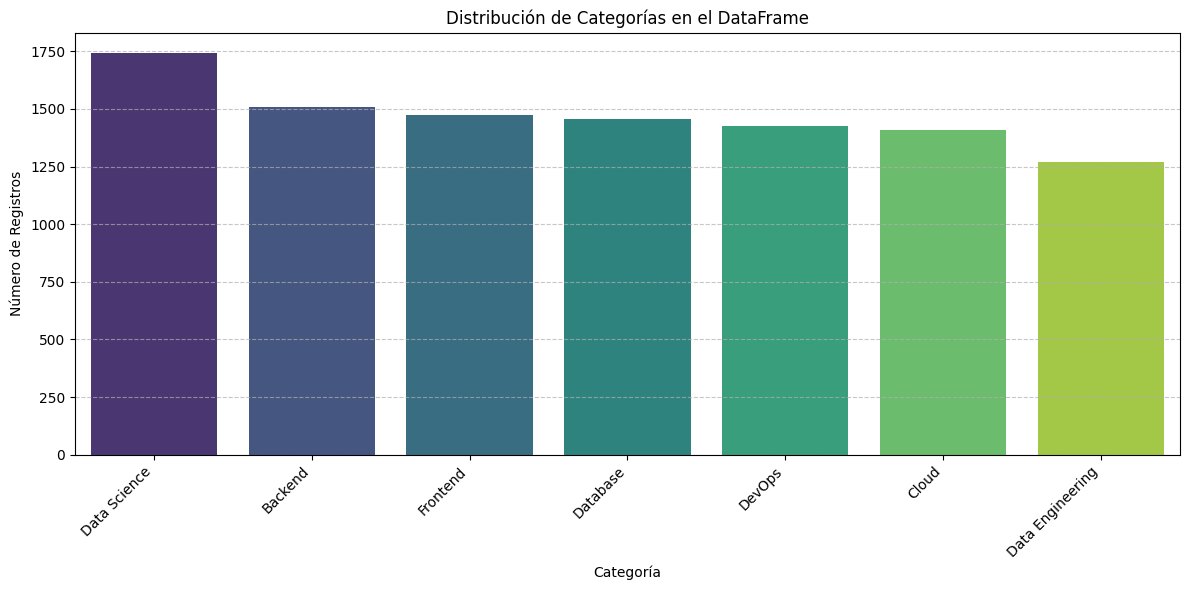

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de cada categoría
category_counts = df['categoria'].value_counts().reset_index()
category_counts.columns = ['categoria', 'count']

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='categoria', y='count', data=category_counts, palette='viridis', hue='categoria', legend=False)
plt.title('Distribución de Categorías en el DataFrame')
plt.xlabel('Categoría')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Visualización de Nube Palabras claves**

In [ ]:
#Intalando recurso requeirido
!pip install wordcloud

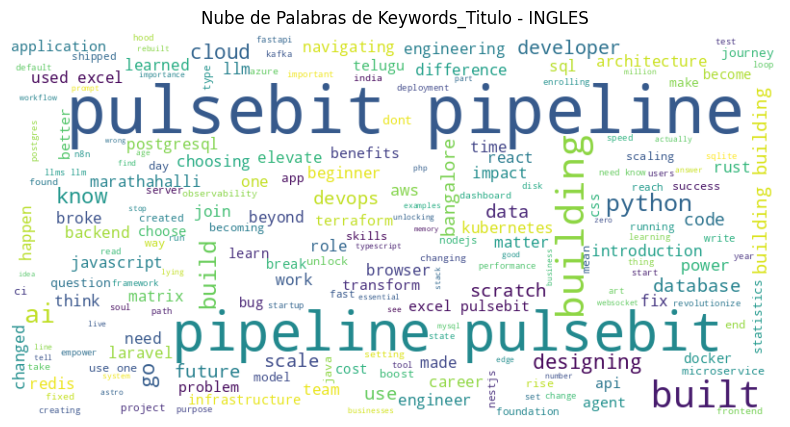

In [ ]:
#'keywords_titulo' - INGLES
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todas las palabras clave de la columna 'keywords_titulo' en una sola cadena de texto
# Primero, asegurarnos de que sean listas de strings y luego unirlas.
all_keywords_titulo = ' '.join([' '.join(map(str, k)) for k in df['keywords_titulo'] if k])

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_titulo)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Titulo - INGLES')
plt.show()

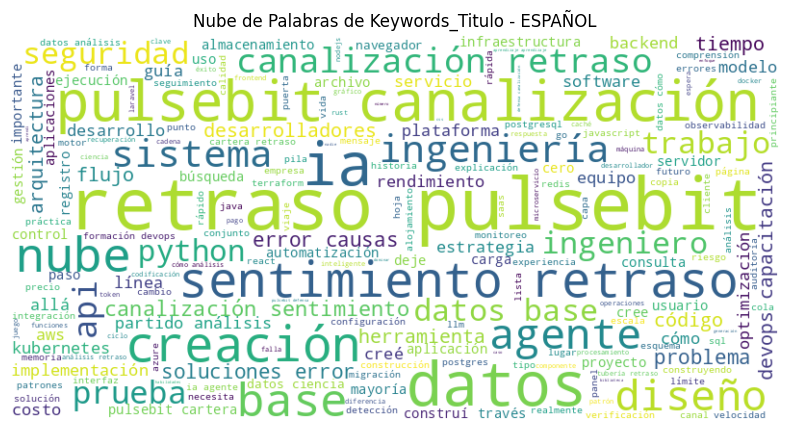

In [ ]:
#keywords_titulo_esp - ESPAÑOL
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todas las palabras clave de la columna 'keywords_titulo_esp' en una sola cadena de texto
# Primero, asegurarnos de que sean listas de strings y luego unirlas.
all_keywords_titulo_esp = ' '.join([' '.join(map(str, k)) for k in df['keywords_titulo_esp'] if k])

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_titulo_esp)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Titulo - ESPAÑOL')
plt.show()

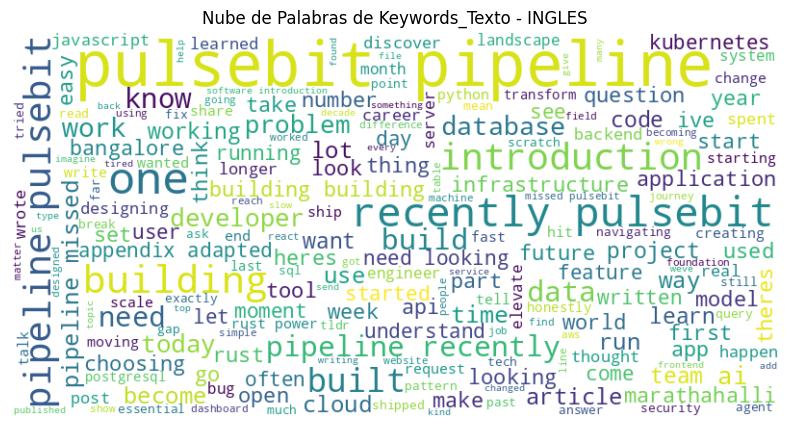

In [ ]:
# Nube de Palabras para 'keywords_texto' - INGLES
# Unir todas las palabras clave de la columna 'keywords_texto' en una sola cadena de texto
all_keywords_texto = ' '.join([' '.join(map(str, k)) for k in df['keywords_texto'] if k])

# Generar la nube de palabras
wordcloud_texto = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_texto)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_texto, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Texto - INGLES')
plt.show()

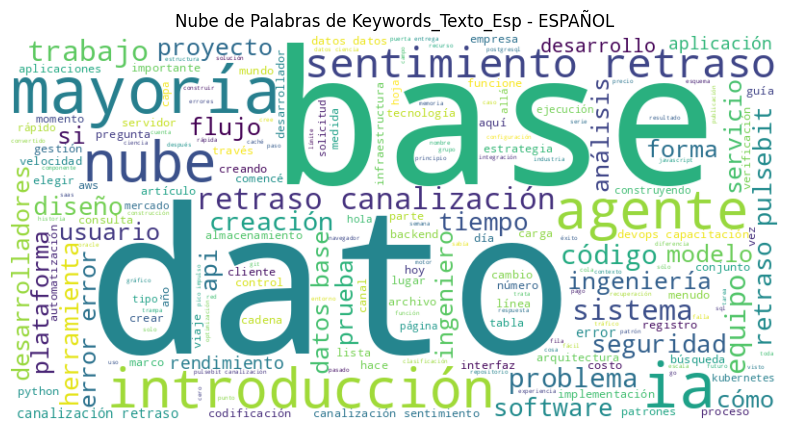

In [ ]:
# Nube de Palabras para 'keywords_texto_esp' - ESPAÑOL
# Unir todas las palabras clave de la columna 'keywords_texto_esp' en una sola cadena de texto
all_keywords_texto_esp_new = ' '.join([' '.join(map(str, k)) for k in df['keywords_texto_esp'] if k])

# Generar la nube de palabras
wordcloud_titulo_esp = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_texto_esp_new)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_titulo_esp, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Texto_Esp - ESPAÑOL')
plt.show()

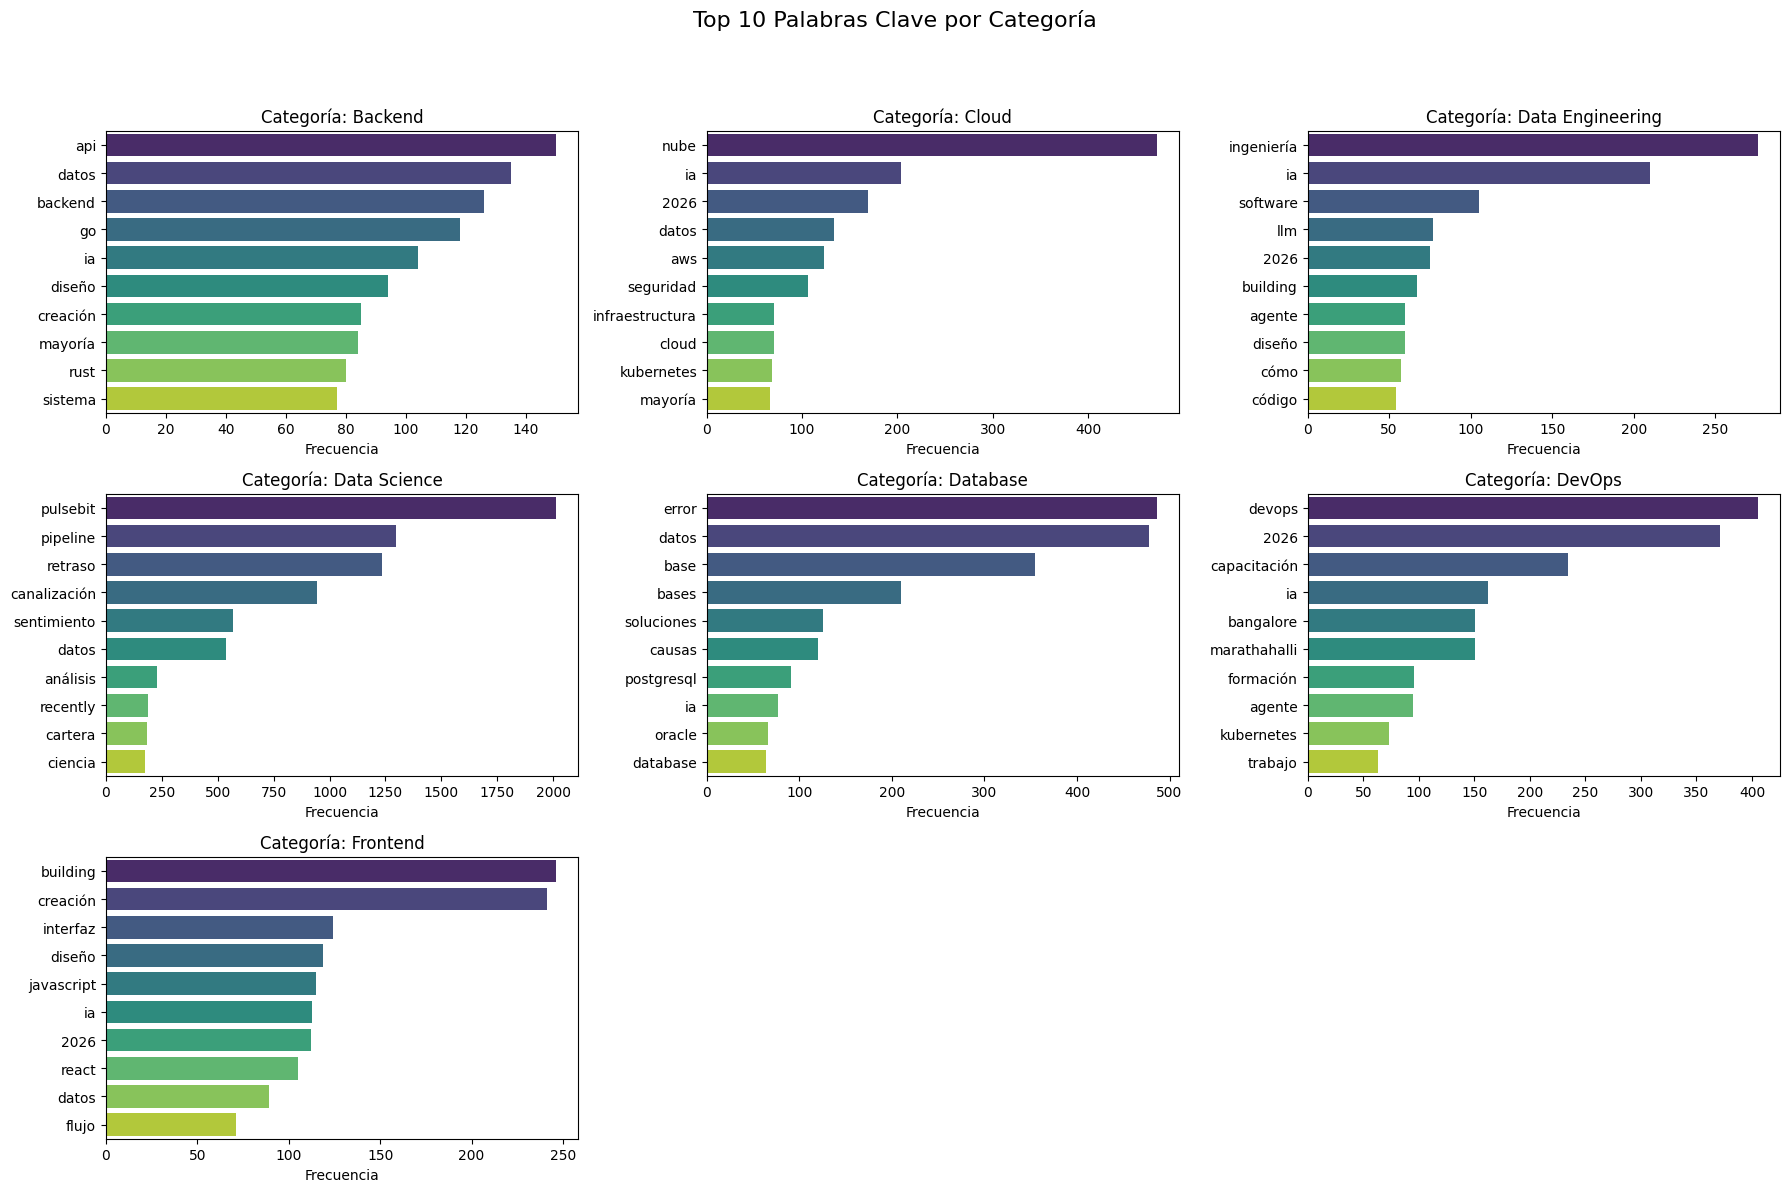

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Preparar un diccionario para almacenar todas las palabras clave combinadas por categoría
# Incluiremos keywords de título y texto, tanto en inglés como en español
all_category_keywords = {
    'Backend': [], 'Cloud': [], 'Data Engineering': [],
    'Data Science': [], 'Database': [], 'DevOps': [], 'Frontend': []
}

# Iterar sobre el DataFrame para combinar las palabras clave por categoría
for index, row in df.iterrows():
    category = row['categoria']

    # Añadir palabras clave de título (inglés)
    if row['keywords_titulo']:
        all_category_keywords[category].extend(row['keywords_titulo'])
    # Añadir palabras clave de texto (inglés)
    if row['keywords_texto']:
        all_category_keywords[category].extend(row['keywords_texto'])
    # Añadir palabras clave de título (español)
    if row['keywords_titulo_esp']:
        all_category_keywords[category].extend(row['keywords_titulo_esp'])
    # Añadir palabras clave de texto (español)
    if row['keywords_texto_esp']:
        all_category_keywords[category].extend(row['keywords_texto_esp'])

# Crear un DataFrame para los datos del gráfico
plot_data = []
for category, keywords_list in all_category_keywords.items():
    # Contar la frecuencia de cada palabra clave
    keyword_counts = Counter(keywords_list)

    # Obtener las 10 palabras clave más comunes
    for keyword, count in keyword_counts.most_common(10):
        plot_data.append({
            'Categoría': category,
            'Palabra Clave': keyword,
            'Frecuencia': count
        })

df_plot = pd.DataFrame(plot_data)

# Generar el gráfico de barras comparativo
fig = plt.figure(figsize=(18, 12)) # Ajustar el tamaño total de la figura
plt.suptitle('Top 10 Palabras Clave por Categoría', fontsize=16, y=1.02) # Título general

# Determinar el número de filas y columnas para los subplots
n_categories = len(all_category_keywords.keys()) # Se corrigió aquí
n_cols = 3 # Por ejemplo, 3 columnas
n_rows = (n_categories + n_cols - 1) // n_cols # Calcular el número de filas necesario

for i, category in enumerate(all_category_keywords.keys()): # Se corrigió aquí
    plt.subplot(n_rows, n_cols, i + 1)
    subset = df_plot[df_plot['Categoría'] == category].sort_values(by='Frecuencia', ascending=False)
    sns.barplot(x='Frecuencia', y='Palabra Clave', data=subset, palette='viridis', hue='Palabra Clave', legend=False)
    plt.title(f'Categoría: {category}')
    plt.xlabel('Frecuencia')
    plt.ylabel('') # Eliminar la etiqueta del eje Y para evitar redundancia
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar diseño para evitar solapamientos y dejar espacio para el título general

plt.show()

In [ ]:
print("Frecuencia de las nuevas palabras clave individuales por categoría:")
display(df_plot.head(10))

Frecuencia de las nuevas palabras clave individuales por categoría:


,Categoría,Palabra Clave,Frecuencia
0,Backend,api,150
1,Backend,datos,135
2,Backend,backend,126
3,Backend,go,118
4,Backend,ia,104
5,Backend,diseño,94
6,Backend,creación,85
7,Backend,mayoría,84
8,Backend,rust,80
9,Backend,sistema,77


### Análisis de Correlación: Palabras Clave Distintivas por Categoría (TF-IDF)

Para identificar las palabras clave que son más "representativas" o "correlacionan" fuertemente con cada categoría, utilizaremos la métrica **TF-IDF (Term Frequency-Inverse Document Frequency)**.

**¿Qué es TF-IDF?**

TF-IDF es una medida estadística que evalúa la importancia de una palabra para un documento en una colección o corpus. Cuanto mayor es el valor de TF-IDF, más importante es la palabra para el documento o categoría.

*   **Term Frequency (TF)**: Mide con qué frecuencia aparece una palabra en una categoría. Una TF alta indica que la palabra es importante dentro de esa categoría.

*   **Inverse Document Frequency (IDF)**: Mide la importancia general de una palabra. Si una palabra aparece en muchos documentos (categorías), su IDF será bajo, lo que significa que no es muy distintiva. Si aparece en pocos documentos, su IDF será alto, indicando que es más específica.

Al multiplicar TF por IDF, obtenemos una puntuación que favorece las palabras que son frecuentes en una categoría específica pero raras en el resto de las categorías, haciéndolas distintivas.

Palabras clave más distintivas (por TF-IDF) por categoría:

--- Categoría: Backend ---
go          0.261743
api         0.258390
datos       0.232551
backend     0.217047
ia          0.179150
diseño      0.161924
rust        0.156210
creación    0.146421
mayoría     0.144698
sistema     0.132640
Name: Backend, dtype: float64

--- Categoría: Cloud ---
nube              0.637471
ia                0.275517
2026              0.228247
aws               0.188303
datos             0.179626
seguridad         0.143161
alojamiento       0.136438
kubernetes        0.104102
azure             0.101253
almacenamiento    0.096448
Name: Cloud, dtype: float64

--- Categoría: Data Engineering ---
ingeniería     0.486981
ia             0.370529
software       0.185265
pcb            0.172628
fabricación    0.138944
llm            0.135861
2026           0.132332
building       0.118216
agente         0.105865
diseño         0.105865
Name: Data Engineering, dtype: float64

--- Categoría: Data Science ---


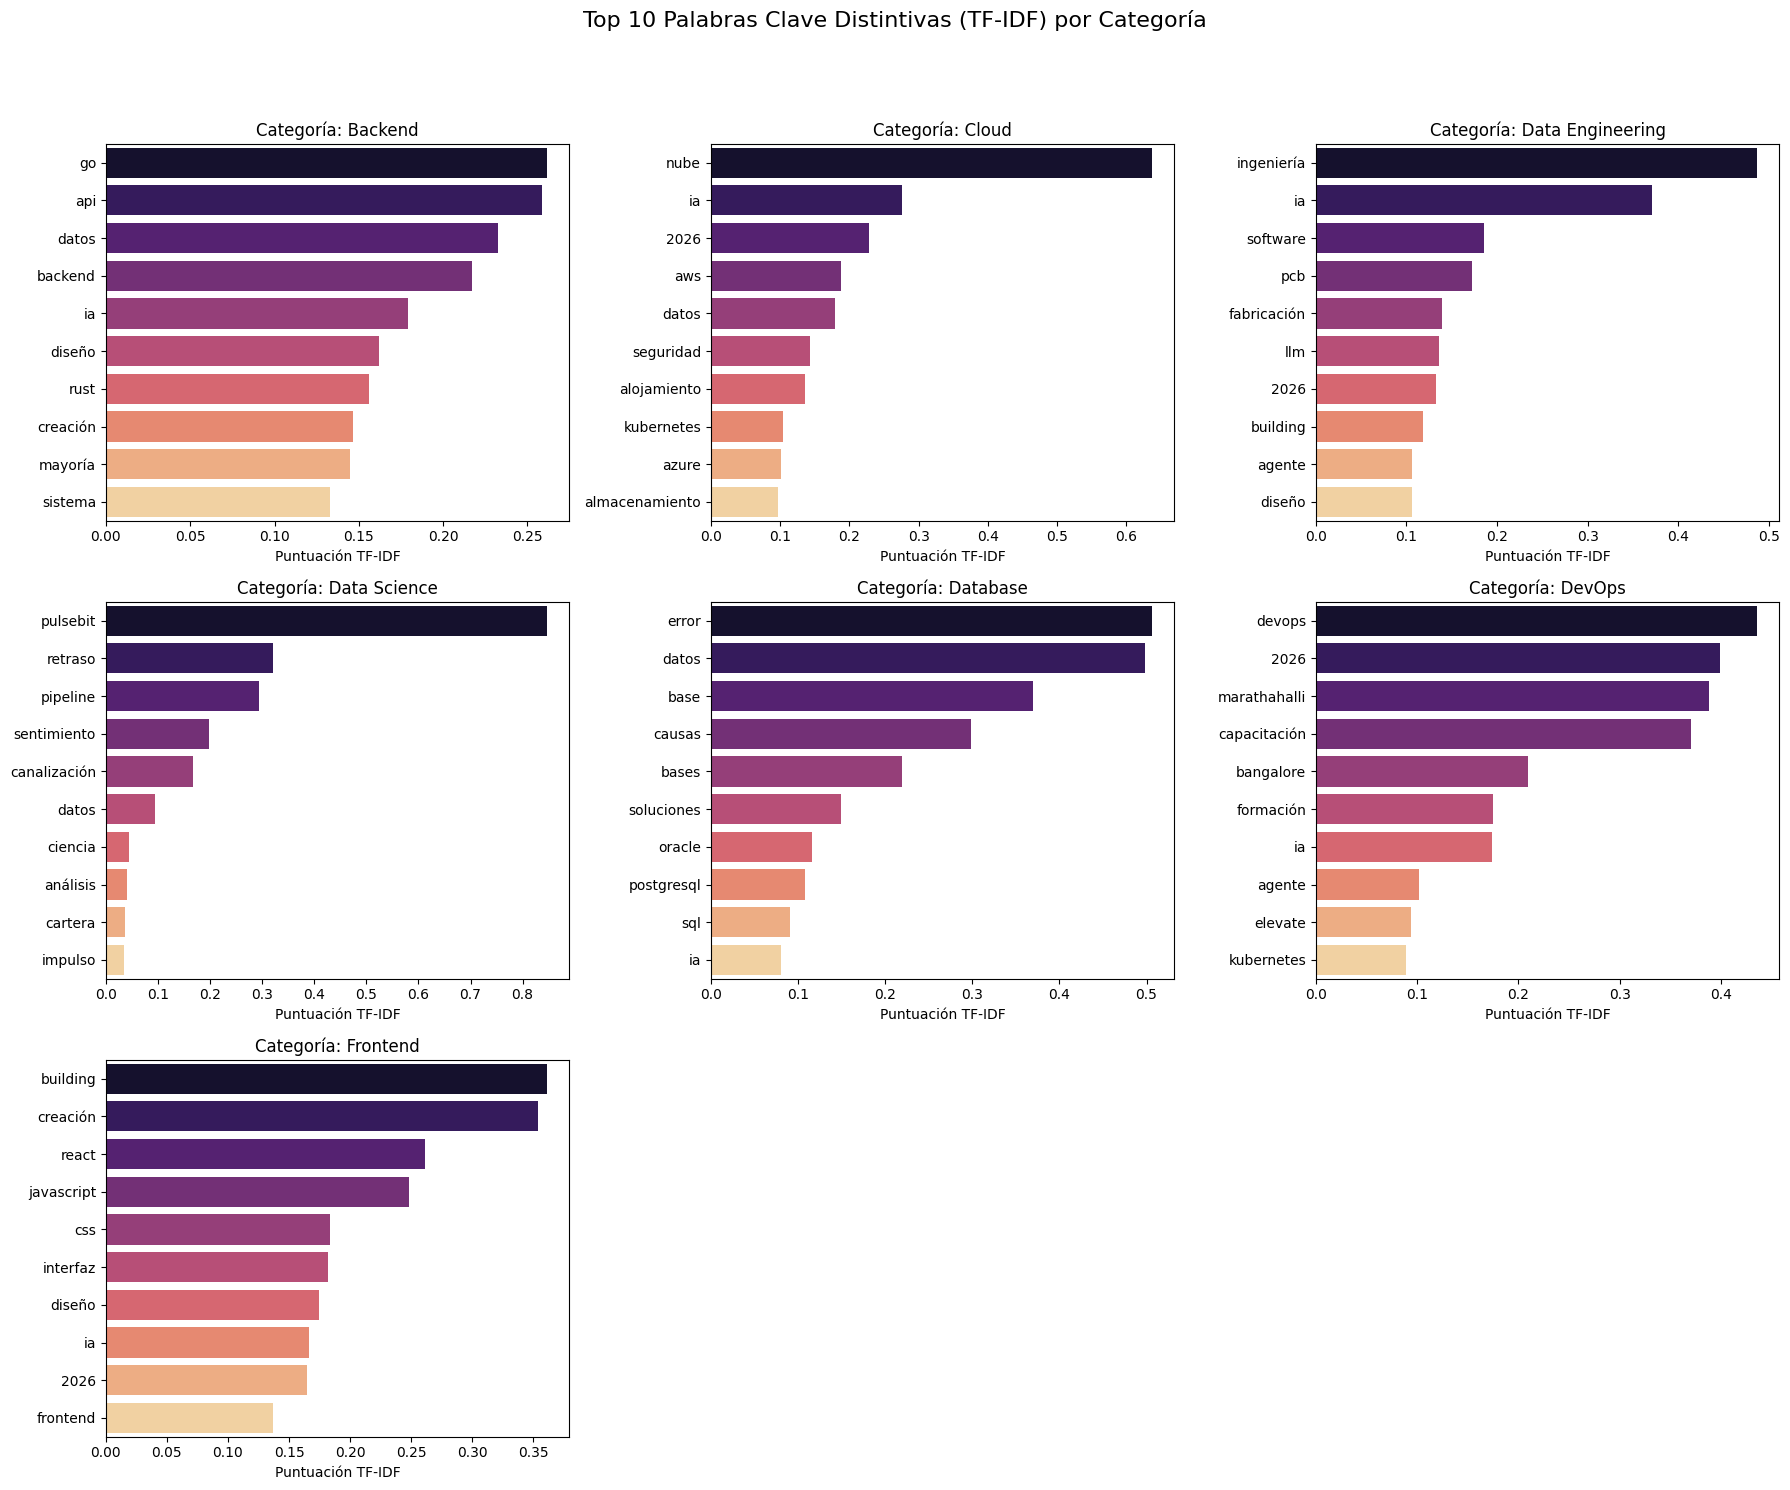

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar documentos para TF-IDF: las palabras clave de cada categoría como una única cadena de texto
category_docs = {}
for category, keywords_list in all_category_keywords.items():
    category_docs[category] = ' '.join(keywords_list)

# Convertir a una lista de documentos en el orden de las categorías
categories_ordered = list(category_docs.keys())
documents = [category_docs[cat] for cat in categories_ordered]

# Calcular TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Obtener nombres de las características (palabras clave)
feature_names = vectorizer.get_feature_names_out()

# Crear un DataFrame para las puntuaciones TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=categories_ordered)

# Identificar y mostrar las palabras clave más distintivas por categoría
print("Palabras clave más distintivas (por TF-IDF) por categoría:")
top_keywords_by_category_tfidf = {}
plot_data_tfidf = []

for category in categories_ordered:
    # Ordenar las palabras clave por su puntuación TF-IDF para la categoría actual
    top_keywords_for_category = tfidf_df.loc[category].sort_values(ascending=False).head(10)
    top_keywords_by_category_tfidf[category] = top_keywords_for_category

    print(f"\n--- Categoría: {category} ---")
    print(top_keywords_for_category)

    for keyword, score in top_keywords_for_category.items():
        plot_data_tfidf.append({
            'Categoría': category,
            'Palabra Clave': keyword,
            'Puntuación TF-IDF': score
        })

df_plot_tfidf = pd.DataFrame(plot_data_tfidf)

# Visualizar las palabras clave más distintivas por categoría en gráficos de barras

n_categories = len(categories_ordered)
n_cols = 3 # Número de columnas para los subplots
n_rows = (n_categories + n_cols - 1) // n_cols # Calcular el número de filas necesario

fig = plt.figure(figsize=(18, n_rows * 5)) # Ajustar el tamaño total de la figura
plt.suptitle('Top 10 Palabras Clave Distintivas (TF-IDF) por Categoría', fontsize=16, y=1.02) # Título general

for i, category in enumerate(categories_ordered):
    plt.subplot(n_rows, n_cols, i + 1)
    subset = df_plot_tfidf[df_plot_tfidf['Categoría'] == category].sort_values(by='Puntuación TF-IDF', ascending=False)
    sns.barplot(x='Puntuación TF-IDF', y='Palabra Clave', data=subset, palette='magma', hue='Palabra Clave', legend=False)
    plt.title(f'Categoría: {category}')
    plt.xlabel('Puntuación TF-IDF')
    plt.ylabel('')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar diseño para evitar solapamientos

plt.show()

### Comparación: Frecuencia vs. TF-IDF para Palabras Clave por Categoría

A continuación, visualizaremos la diferencia entre las palabras clave más frecuentes y las más distintivas (según TF-IDF) para cada categoría. Esto ayudará a entender cómo TF-IDF prioriza palabras que son relevantes para una categoría específica, en lugar de solo las que aparecen con mayor recurrencia en general.

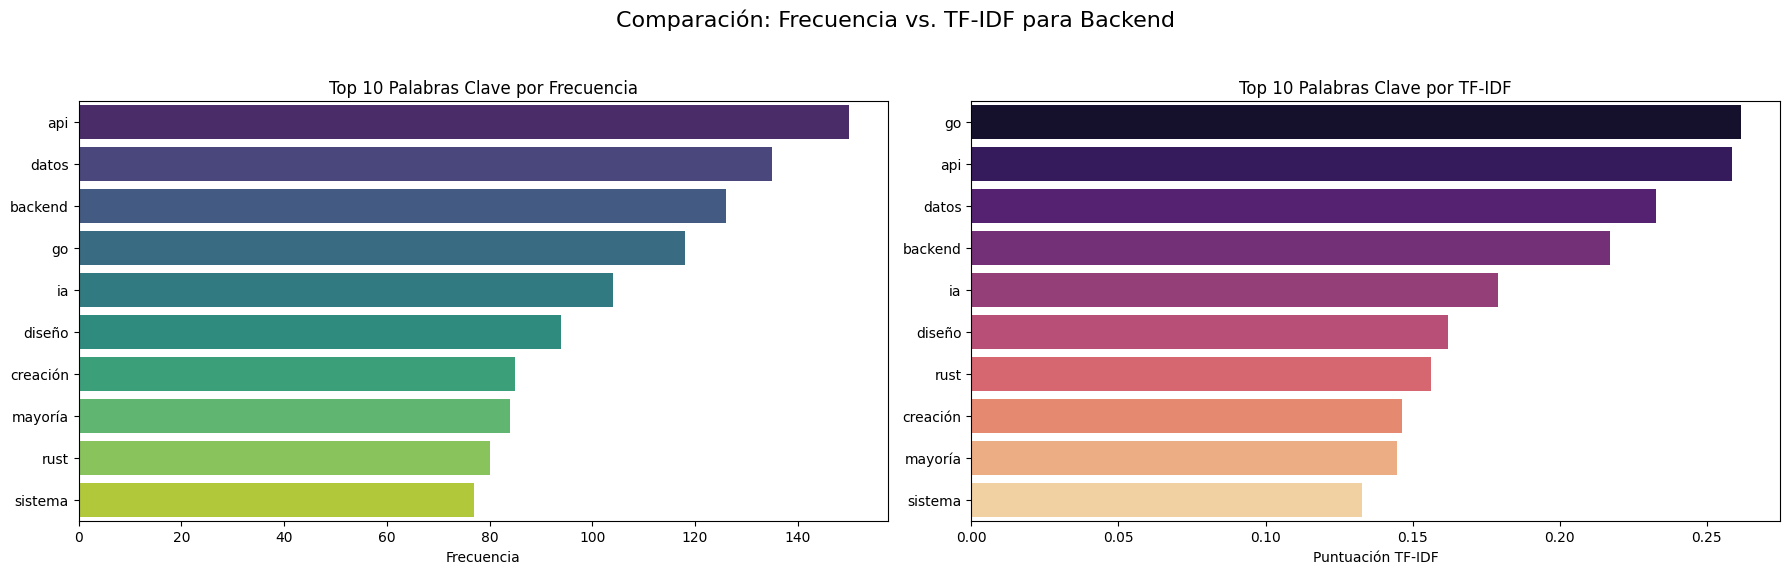

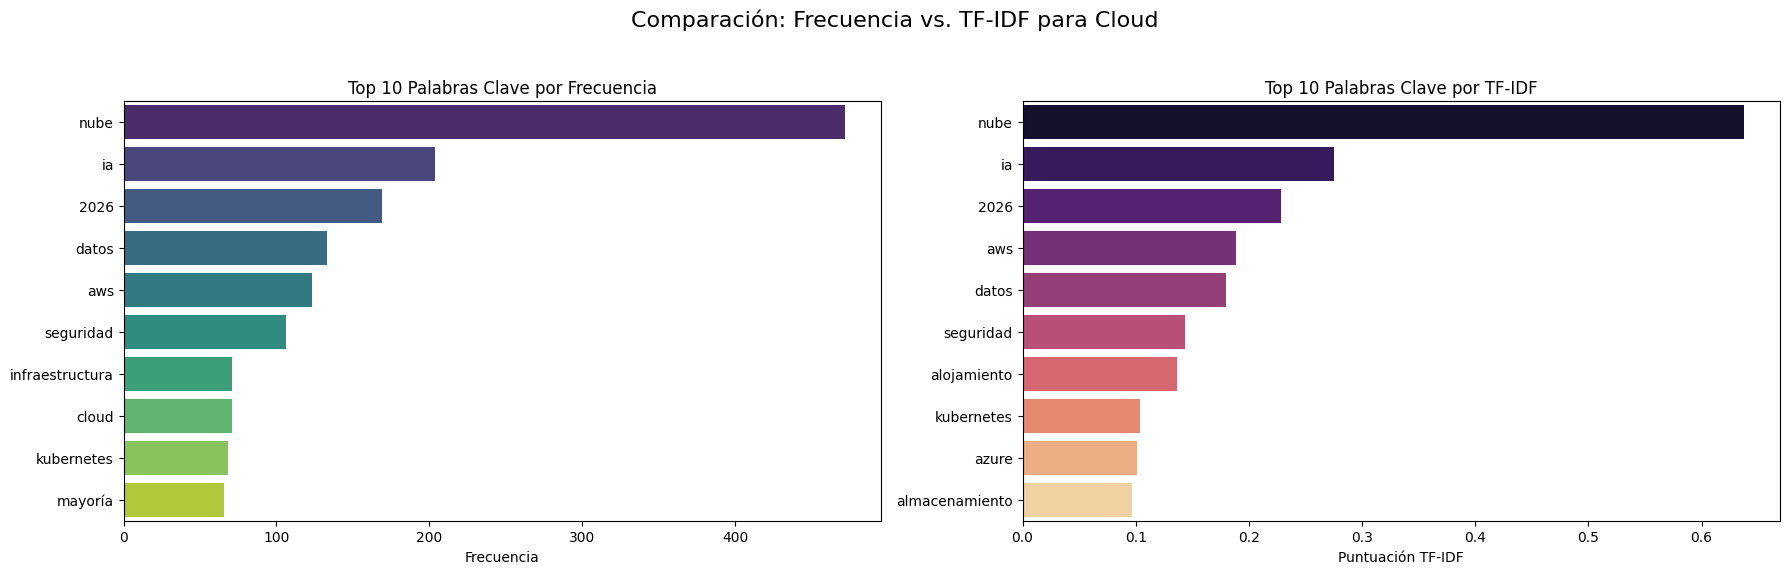

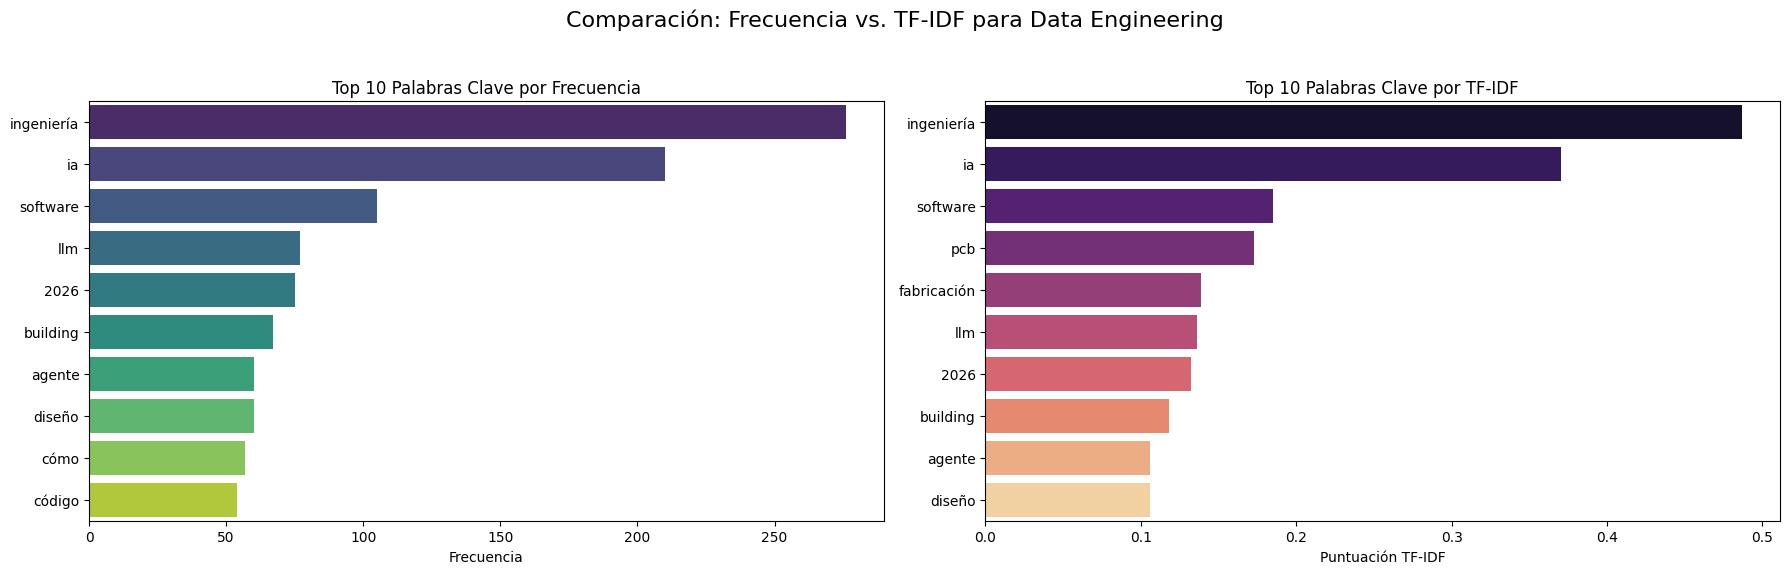

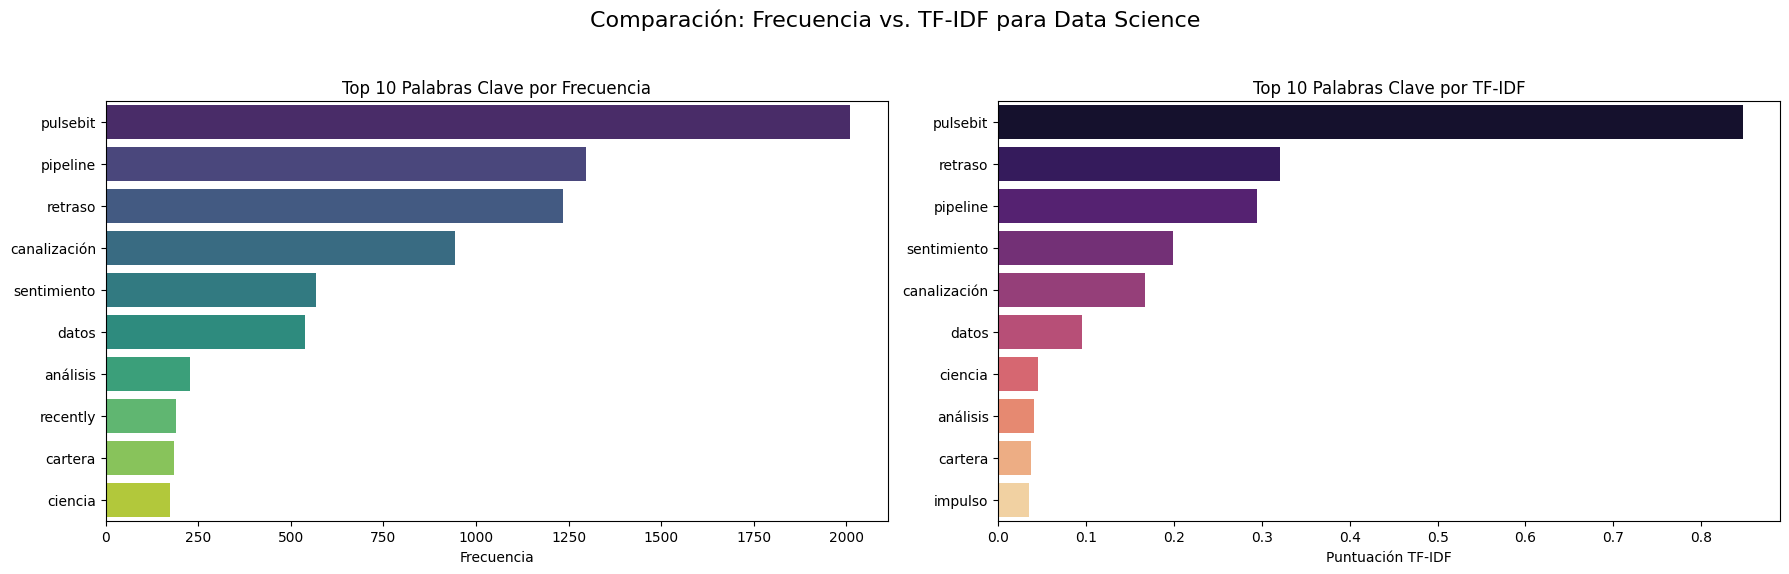

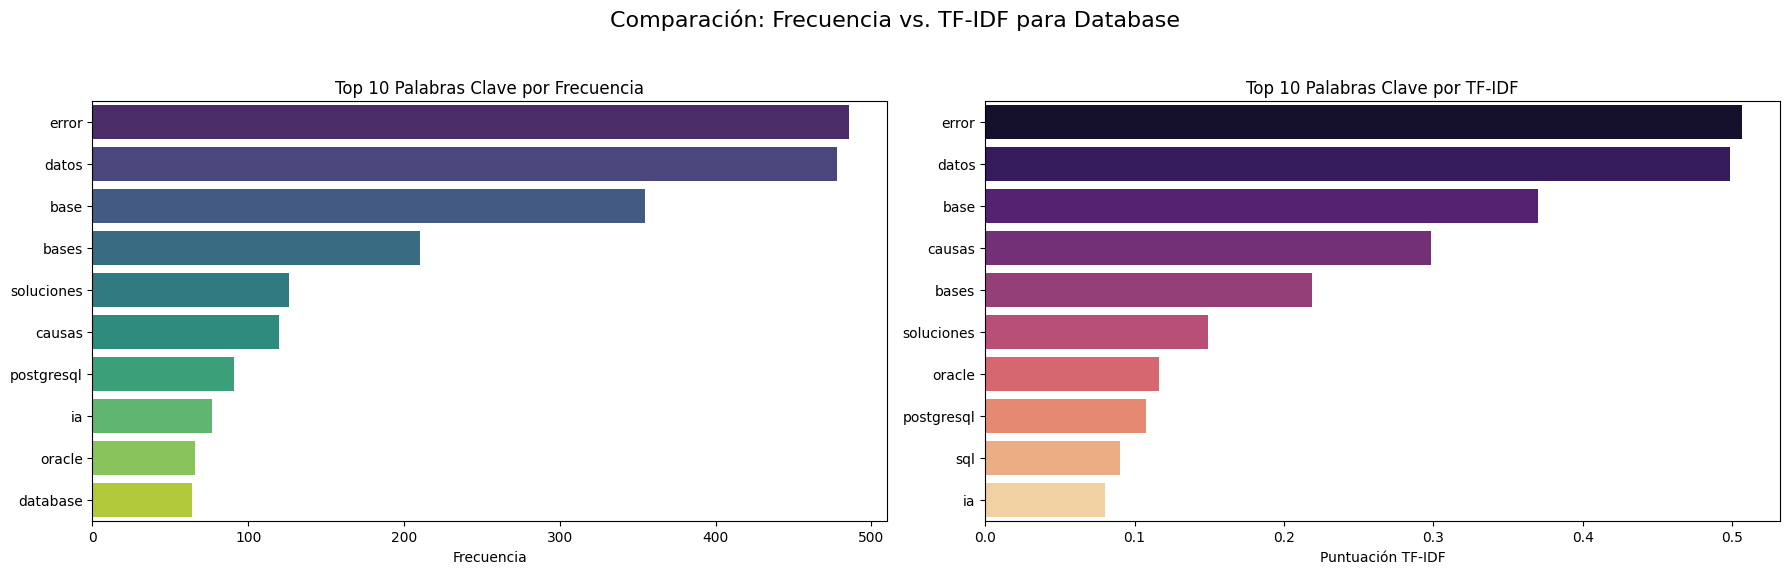

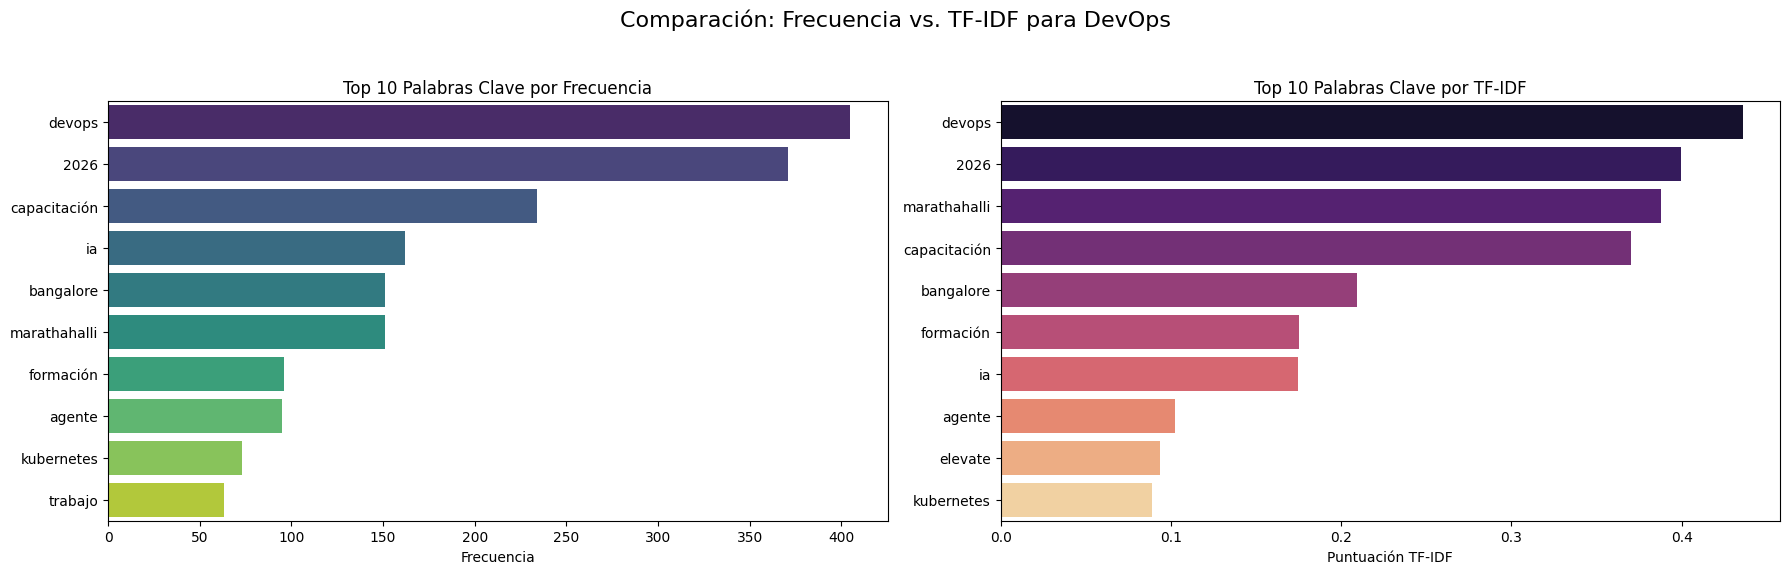

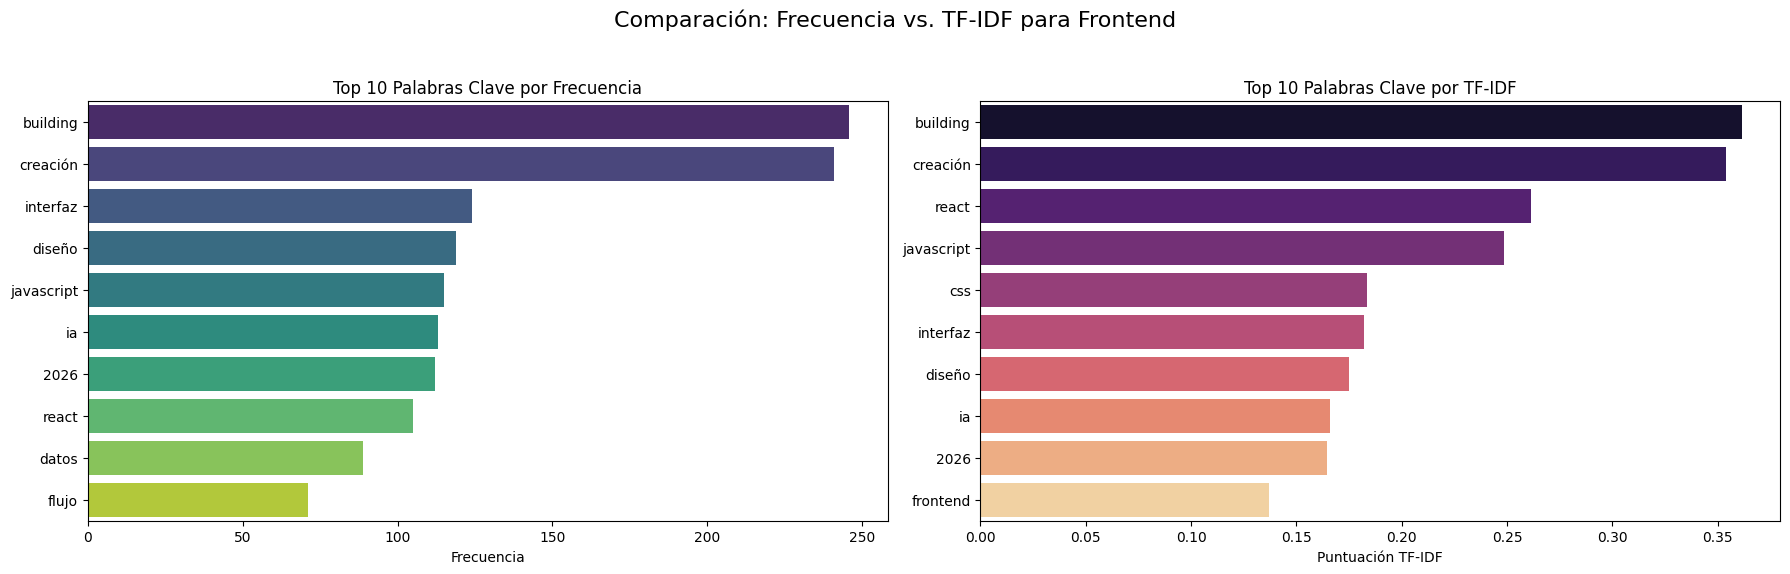

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

categories_list = df_plot['Categoría'].unique()

for category in categories_list:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Un par de subplots por categoría
    fig.suptitle(f'Comparación: Frecuencia vs. TF-IDF para {category}', fontsize=16)

    # Gráfico de Frecuencia
    subset_freq = df_plot[df_plot['Categoría'] == category].sort_values(by='Frecuencia', ascending=False)
    sns.barplot(ax=axes[0], x='Frecuencia', y='Palabra Clave', data=subset_freq, palette='viridis', hue='Palabra Clave', legend=False)
    axes[0].set_title('Top 10 Palabras Clave por Frecuencia')
    axes[0].set_xlabel('Frecuencia')
    axes[0].set_ylabel('')

    # Gráfico de TF-IDF
    subset_tfidf = df_plot_tfidf[df_plot_tfidf['Categoría'] == category].sort_values(by='Puntuación TF-IDF', ascending=False)
    sns.barplot(ax=axes[1], x='Puntuación TF-IDF', y='Palabra Clave', data=subset_tfidf, palette='magma', hue='Palabra Clave', legend=False)
    axes[1].set_title('Top 10 Palabras Clave por TF-IDF')
    axes[1].set_xlabel('Puntuación TF-IDF')
    axes[1].set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar diseño para el título general
    plt.show()

### Tabla Resumen: Comparación de Frecuencia vs. TF-IDF por Categoría

La siguiente tabla presenta las palabras clave más relevantes, comparando su frecuencia de aparición con su puntuación TF-IDF. Esto permite identificar tanto las palabras clave comunes como las más distintivas para cada categoría.

In [ ]:
import pandas as pd

# Unir los DataFrames de frecuencia y TF-IDF
df_summary = pd.merge(
    df_plot,
    df_plot_tfidf,
    on=['Categoría', 'Palabra Clave'],
    how='outer'  # Usar outer join para incluir todas las palabras clave de ambos rankings
)

# Renombrar columnas para mayor claridad
df_summary.rename(columns={
    'Frecuencia': 'Frecuencia_Palabra_Clave',
    'Puntuación TF-IDF': 'TFIDF_Puntuación'
}, inplace=True)

# Rellenar valores NaN con 0 (en caso de que una palabra clave aparezca en un ranking pero no en el otro)
df_summary.fillna(0, inplace=True)

# Ordenar para una mejor visualización
df_summary = df_summary.sort_values(by=['Categoría', 'Frecuencia_Palabra_Clave', 'TFIDF_Puntuación'], ascending=[True, False, False])

display(df_summary.head(20))

,Categoría,Palabra Clave,Frecuencia_Palabra_Clave,TFIDF_Puntuación
0,Backend,api,150.0,0.258390
3,Backend,datos,135.0,0.232551
1,Backend,backend,126.0,0.217047
5,Backend,go,118.0,0.261743
6,Backend,ia,104.0,0.179150
4,Backend,diseño,94.0,0.161924
2,Backend,creación,85.0,0.146421
7,Backend,mayoría,84.0,0.144698
8,Backend,rust,80.0,0.156210
9,Backend,sistema,77.0,0.132640


**EXPORTANDO DATASET FINAL - FULL Formato EXTENDIDO**

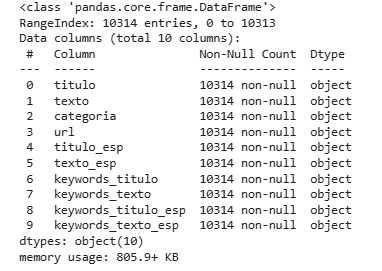

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10290 entries, 0 to 10289
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               10290 non-null  object
 1   texto                10290 non-null  object
 2   categoria            10290 non-null  object
 3   url                  10290 non-null  object
 4   titulo_esp           10290 non-null  object
 5   texto_esp            10290 non-null  object
 6   keywords_titulo      10290 non-null  object
 7   keywords_texto       10290 non-null  object
 8   keywords_titulo_esp  10290 non-null  object
 9   keywords_texto_esp   10290 non-null  object
dtypes: object(10)
memory usage: 804.0+ KB


In [ ]:
# Exportar dataset full traducido, limpió y con palabras claves
os.makedirs("data", exist_ok=True)
#df.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp_final.csv", sep = ';', index=False, encoding="utf-8-sig")
df.to_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp_final.csv", sep = ';', index=False, encoding="utf-8-sig")
#df.to_json("data/dataset_devto_englesespanol.json", orient="records", force_ascii=False, indent=2)


**EXPORTANDO DATASET FINAL - TRADUCIDOS ESPAÑOL PARA CONSUMIR PROTOTIPO (dataset.csv)**


**Formato requerido**

titulo: título del contenido técnico en Español.


texto: descripción, resumen o extracto técnico en español.


categoria: categorías (Backend, Frontend, Data Engineering, Cloud, DevOps, Database).

In [ ]:
# Crear un nuevo DataFrame con las columnas deseadas y sus nuevos nombres
df_para_prototipo = df[['titulo_esp', 'texto_esp', 'categoria']].copy()
df_para_prototipo.rename(columns={'titulo_esp': 'titulo', 'texto_esp': 'texto'}, inplace=True)

# Exportar el DataFrame a un archivo CSV
os.makedirs("data", exist_ok=True)
#df_para_prototipo.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_final_prototipo.csv", sep = ';', index=False, encoding="utf-8-sig")
df_para_prototipo.to_csv("/content/sample_data/dataset.csv", sep = ';', index=False, encoding="utf-8-sig")

print("DataFrame 'dataset.csv' creado y guardado en /content/sample_data/")
print("Primeras 5 filas del DataFrame exportado:")
display(df_para_prototipo.head())

DataFrame 'dataset.csv' creado y guardado en /content/sample_data/
Primeras 5 filas del DataFrame exportado:


,titulo,texto,categoria
0,Llevar la convención a la configuración para F...,Hola a todos 👋 Si disfrutan del rendimiento de...,Backend
1,Su API volvió a intentar la solicitud. A su cl...,"Un cliente hace clic en el botón Pagar, el ser...",Backend
2,Colas de mensajes fallidos de RabbitMQ en .NET...,Cómo protegemos un panel de administración de ...,Backend
3,"Parte 5: palabra clave sincronizada: métodos, ...","En el artículo anterior, exploramos la palabra...",Backend
4,Fortalecimiento de un panel de administración ...,"Valide lo que entra, dé forma a lo que sale y ...",Backend


**###TAREA TRELLO: SPRINT-S1_DS-02: Exploración y limpieza de datos (EDA)**

https://trello.com/c/Sec9dVu9/60-sprint-s1ds-02-exploraci%C3%B3n-y-limpieza-de-datos-eda


**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

**DATASET INICIAL - Formato Extendido**
Archivo: dataset_inicial_devto_hackaton_eng_esp_final.csv

_____________________________________________________________

### Importando archivo de resultado recolección de datos

Dataset base formanto extendido
"**dataset_inicial_devto_hackaton_eng_esp_final.csv**", se ha decidido usar este archivo para cargar en aplicación prototipo.

In [ ]:
#Cargando archivo de resultado
import pandas as pd
#df = pd.read_csv('/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp_final.csv', sep = ';')

#--- Pueden cambiar ruta almacenada en su drive, ya que si se desconecta desaparece el archivo
df = pd.read_csv('/content/sample_data/dataset.csv/dataset_inicial_devto_hackaton_eng_esp_final.csv', sep = ';')
#df = pd.read_csv('/content/sample_data/dataset.csv', sep = ';')

**Información General del DataFrame**

Entender los tipos de datos, estructura del dataset y la cantidad de valores no nulos en cada columna.

In [ ]:
#Información de datasetLimpieza y  Análisis exploratorio EDA
print('Información del DataFrame df:')
df.info()
print('\nPrimeras 5 filas del DataFrame df:')
display(df.head())

Información del DataFrame df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10290 entries, 0 to 10289
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               10290 non-null  object
 1   texto                10290 non-null  object
 2   categoria            10290 non-null  object
 3   url                  10290 non-null  object
 4   titulo_esp           10290 non-null  object
 5   texto_esp            10290 non-null  object
 6   keywords_titulo      10290 non-null  object
 7   keywords_texto       10290 non-null  object
 8   keywords_titulo_esp  10290 non-null  object
 9   keywords_texto_esp   10290 non-null  object
dtypes: object(10)
memory usage: 804.0+ KB

Primeras 5 filas del DataFrame df:


,titulo,texto,categoria,url,titulo_esp,texto_esp,keywords_titulo,keywords_texto,keywords_titulo_esp,keywords_texto_esp
0,Bringing Convention over Configuration to Fast...,Hi everyone 👋 If you enjoy Fastify's performa...,Backend,https://dev.to/domutala/bringing-convention-ov...,Llevar la convención a la configuración para F...,Hola a todos 👋 Si disfrutan del rendimiento de...,"['syorafastify', 'fastify', 'configuration']",[],"['syorafastify', 'llevar', 'fastify', 'convenc...","['veces', 'rendimiento', 'pierden', 'hola', 'f..."
1,Your API Retried the Request. Your Customer Go...,"A customer clicks the Pay button, the server s...",Backend,https://dev.to/vikrant_bhalodia/your-api-retri...,Su API volvió a intentar la solicitud. A su cl...,"Un cliente hace clic en el botón Pagar, el ser...",['request'],"['request', 'charge']","['solicitud', 'intentar', 'cliente']","['solicitud', 'proveedor', 'pago', 'cargo']"
2,RabbitMQ Dead Letter Queues in .NET: Why We Ch...,"In a message-based system, one of the first qu...",Backend,https://dev.to/ben-witt/rabbitmq-dead-letter-q...,Colas de mensajes fallidos de RabbitMQ en .NET...,Cómo protegemos un panel de administración de ...,"['net', 'chose', 'approach']","['happens', 'answer']","['rabbitmq', 'net', 'enfoque', 'elegimos', 'dó...","['panel', 'hmac', 'administración']"
3,"Part 5 - synchronized Keyword: Methods, Blocks...","In the previous article, we explored the nativ...",Backend,https://dev.to/rajeshbhola1/part-5-synchronize...,"Parte 5: palabra clave sincronizada: métodos, ...","En el artículo anterior, exploramos la palabra...",[],"['learned', 'explored', 'cc']",['subprocesos'],"['comunica', 'cc']"
4,Hardening a PHP Video Admin Panel With CSRF Do...,How we protect a PHP 8.4 video admin panel fro...,Backend,https://dev.to/ahmet_gedik778845/hardening-a-p...,Fortalecimiento de un panel de administración ...,"Valide lo que entra, dé forma a lo que sale y ...",['hardening'],['protect'],"['panel', 'fortalecimiento', 'cookies', 'admin...","['valide', 'sale', 'código', 'asigne']"


In [ ]:
#Verificación de valores nulos en los atributos
df.isnull().sum()

,0
titulo,0
texto,0
categoria,0
url,0
titulo_esp,0
texto_esp,0
keywords_titulo,0
keywords_texto,0
keywords_titulo_esp,0
keywords_texto_esp,0


### Distribución de Categorías

Visualizaremos la distribución de artículos por cada categoría para asegurarnos de que estén balanceadas.

/tmp/ipykernel_400/3358680042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='categoria', order=df['categoria'].value_counts().index, palette='viridis')


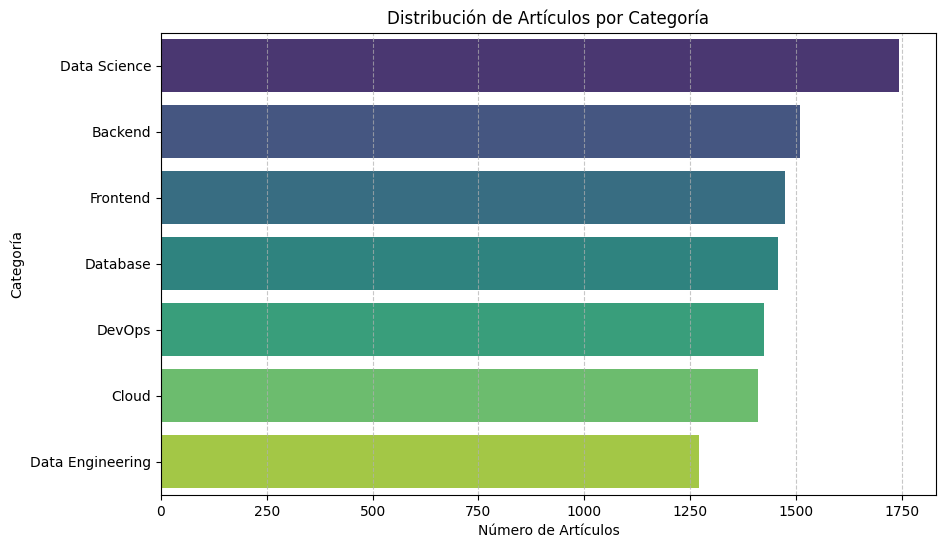

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='categoria', order=df['categoria'].value_counts().index, palette='viridis')
plt.title('Distribución de Artículos por Categoría')
plt.xlabel('Número de Artículos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análisis de Longitud de Títulos y Textos

Análisis a la longitud de los títulos y textos (en inglés y español) para entender su distribución.

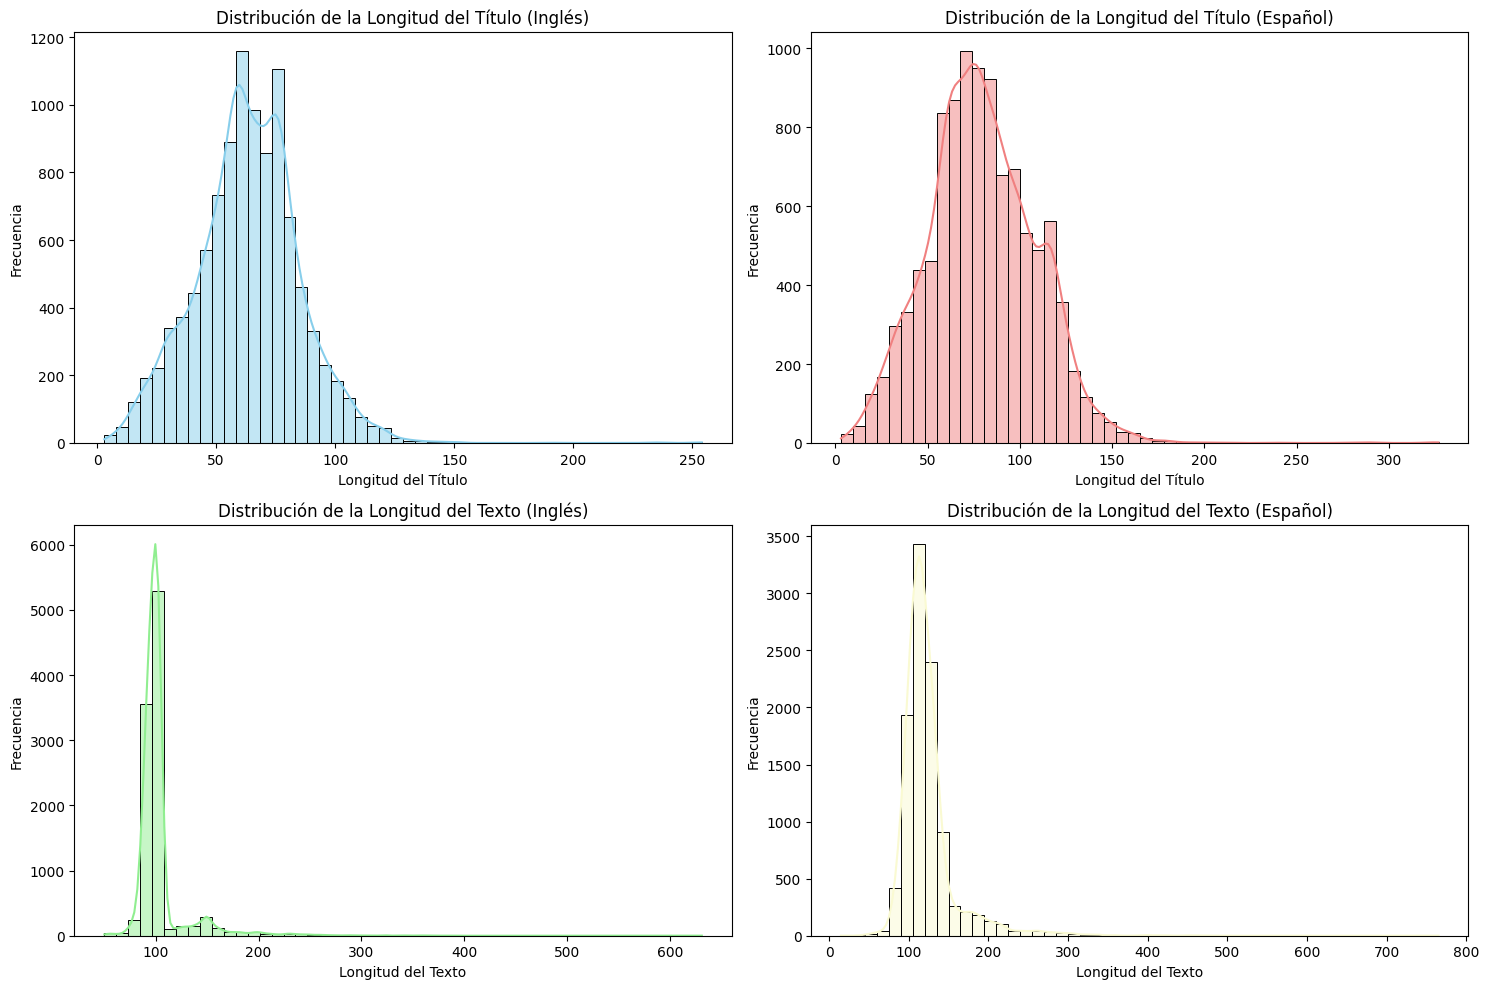


Estadísticas descriptivas para la longitud de títulos y textos:


,titulo_len,texto_len,titulo_esp_len,texto_esp_len
count,10290.000000,10290.000000,10290.000000,10290.000000
mean,63.533722,103.920700,79.726822,123.923907
std,21.820553,26.389553,29.388737,36.535157
min,3.000000,50.000000,3.000000,15.000000
25%,50.000000,94.000000,60.000000,105.000000
50%,64.000000,99.000000,78.000000,116.000000
75%,77.000000,103.000000,99.000000,130.000000
max,254.000000,631.000000,327.000000,765.000000


In [ ]:
df['titulo_len'] = df['titulo'].apply(len)
df['texto_len'] = df['texto'].apply(len)
df['titulo_esp_len'] = df['titulo_esp'].apply(len)
df['texto_esp_len'] = df['texto_esp'].apply(len)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['titulo_len'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la Longitud del Título (Inglés)')
plt.xlabel('Longitud del Título')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 2)
sns.histplot(df['titulo_esp_len'], bins=50, kde=True, color='lightcoral')
plt.title('Distribución de la Longitud del Título (Español)')
plt.xlabel('Longitud del Título')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 3)
sns.histplot(df['texto_len'], bins=50, kde=True, color='lightgreen')
plt.title('Distribución de la Longitud del Texto (Inglés)')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 4)
sns.histplot(df['texto_esp_len'], bins=50, kde=True, color='lightgoldenrodyellow')
plt.title('Distribución de la Longitud del Texto (Español)')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas para la longitud de títulos y textos:')
display(df[['titulo_len', 'texto_len', 'titulo_esp_len', 'texto_esp_len']].describe())

### Análisis de Cantidad de Palabras Clave Extraídas

Exploramos cuántas palabras clave se extrajeron por cada título y texto.

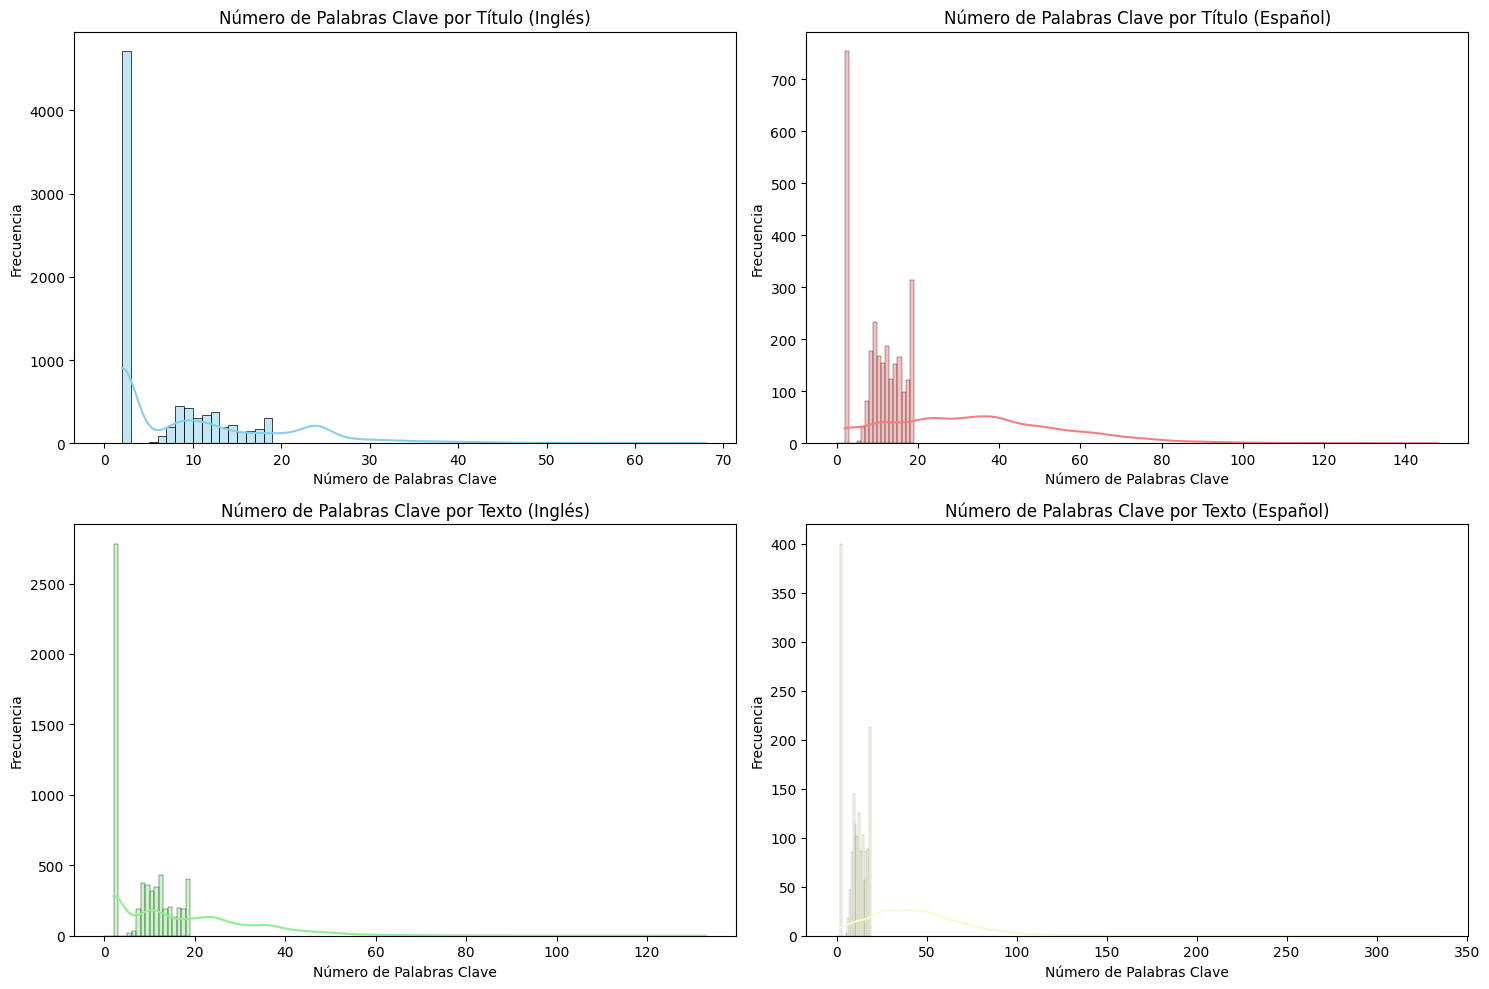


Estadísticas descriptivas para el número de palabras clave:


,num_keywords_titulo,num_keywords_texto,num_keywords_titulo_esp,num_keywords_texto_esp
count,10290.000000,10290.000000,10290.000000,10290.000000
mean,10.547522,17.799417,34.338970,44.560447
std,10.390693,15.281351,21.187255,26.913061
min,2.000000,2.000000,2.000000,2.000000
25%,2.000000,2.000000,18.000000,26.000000
50%,8.000000,14.000000,33.000000,42.000000
75%,17.000000,27.000000,48.000000,59.000000
max,68.000000,133.000000,148.000000,334.000000


In [ ]:
df['num_keywords_titulo'] = df['keywords_titulo'].apply(len)
df['num_keywords_texto'] = df['keywords_texto'].apply(len)
df['num_keywords_titulo_esp'] = df['keywords_titulo_esp'].apply(len)
df['num_keywords_texto_esp'] = df['keywords_texto_esp'].apply(len)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['num_keywords_titulo'], bins=range(0, 20), kde=True, color='skyblue')
plt.title('Número de Palabras Clave por Título (Inglés)')
plt.xlabel('Número de Palabras Clave')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 2)
sns.histplot(df['num_keywords_titulo_esp'], bins=range(0, 20), kde=True, color='lightcoral')
plt.title('Número de Palabras Clave por Título (Español)')
plt.xlabel('Número de Palabras Clave')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 3)
sns.histplot(df['num_keywords_texto'], bins=range(0, 20), kde=True, color='lightgreen')
plt.title('Número de Palabras Clave por Texto (Inglés)')
plt.xlabel('Número de Palabras Clave')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 4)
sns.histplot(df['num_keywords_texto_esp'], bins=range(0, 20), kde=True, color='lightgoldenrodyellow')
plt.title('Número de Palabras Clave por Texto (Español)')
plt.xlabel('Número de Palabras Clave')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas para el número de palabras clave:')
display(df[['num_keywords_titulo', 'num_keywords_texto', 'num_keywords_titulo_esp', 'num_keywords_texto_esp']].describe())